In [136]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [ ]:
fn=pd.read_csv(r"C:\Users\franc\Downloads\Fn_comp_major_minor.csv")


In [7]:
mae_maj_on=fn.loc[fn["Fn"]=="on","MAE Major"]
mae_min_on=fn.loc[fn["Fn"]=="on","MAE Minor"]
mae_maj_off=fn.loc[fn["Fn"]=="off","MAE Major"]
mae_min_off=fn.loc[fn["Fn"]=="off","MAE Minor"]




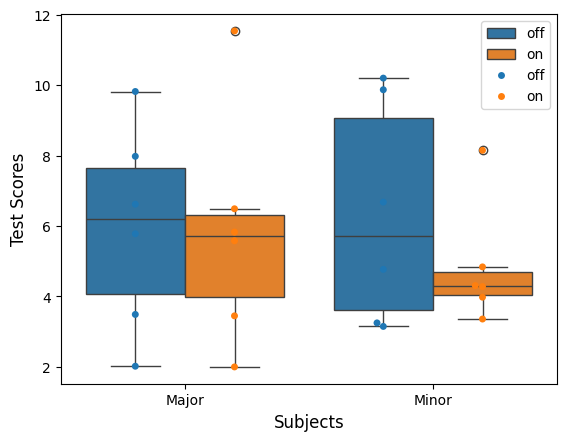

In [118]:
sns.boxplot(x='Axis', y='MAE', hue='Fn', data=fn)
sns.swarmplot(x="Axis", y='MAE', hue="Fn",  data=fn,dodge=True)

plt.xlabel("Subjects", size=12)
plt.ylabel("Test Scores", size=12)
plt.legend(loc='upper right')
plt.show()

<Axes: xlabel='Axis', ylabel='Corr'>

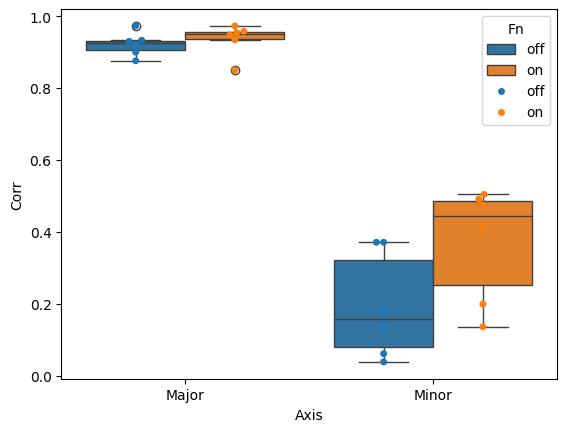

In [117]:
xx="Axis"
hh="Fn"

fn_on =fn.loc[fn["Axis"]=="Major"]
# print(fn_on)

sns.boxplot(x=xx, y='Corr', hue=hh, data=fn)

sns.swarmplot(x=xx, y='Corr', hue=hh,  data=fn,dodge=True)

# sns.lineplot(data=may_flights, x="year", y="passengers")
# (sns.lineplot(x=xx, y='Corr', hue=hh,  units="Trunk",estimator=None,data=fn))
# plt.show()

<Axes: xlabel='Fn', ylabel='Corr'>

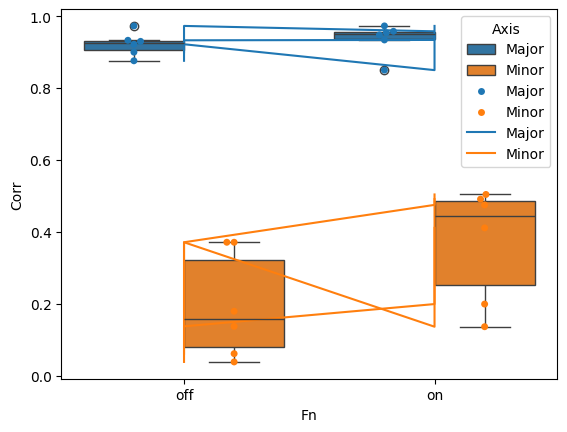

In [69]:
xx="Fn"
hh="Axis"

fn_on =fn.loc[fn["Axis"]=="Major"]
# print(fn_on)

sns.boxplot(x=xx, y='Corr', hue=hh, data=fn)

sns.swarmplot(x=xx, y='Corr', hue=hh,  data=fn,dodge=True)

# sns.lineplot(data=may_flights, x="year", y="passengers")
(sns.lineplot(x=xx, y='Corr', hue=hh,  units="Trunk",estimator=None,data=fn))
# plt.show()

In [288]:

# fig = px.box(fn, y="Corr", facet_col="Axis", color="Fn",
#              boxmode="group", points='all')
metric="Corr"

fn_on_major =fn.loc[(fn["Axis"]=="Major") & (fn["Fn"]=="on")]
fn_off_major =fn.loc[(fn["Axis"]=="Major")&(fn["Fn"]=="off")]
fn_on_minor =fn.loc[(fn["Axis"]=="Minor")&(fn["Fn"]=="on")]
fn_off_minor =fn.loc[(fn["Axis"]=="Minor")&(fn["Fn"]=="off")]



fn_major =fn.loc[(fn["Axis"]=="Major") ]
fn_minor =fn.loc[(fn["Axis"]=="Minor")]

color1='rgb(68,86,141)'
color2='rgb(125,48,98)'

# fig = px.strip(fn_major, y="Corr", x="Fn",color="Fn",stripmode='overlay')
fig = make_subplots(rows=1, cols=2,shared_yaxes=True,)

fig.add_trace(go.Box( y=fn_major.query('Fn == "off"')[metric],name="off",marker_color=color1,
    line_color=color1),row=1, col=1)
fig.add_trace(go.Box( y=fn_major.query('Fn == "on"')[metric],name="on",marker_color=color2,
    line_color=color2),row=1, col=1)

fig.add_trace(go.Box( y=fn_minor.query('Fn == "off"')[metric],name="off",marker_color=color1,
    line_color=color1,showlegend=False),row=1, col=2)
fig.add_trace(go.Box( y=fn_minor.query('Fn == "on"')[metric],name="on",marker_color=color2,
    line_color=color2,showlegend=False),row=1, col=2)

mat_major=(np.stack((fn_off_major[metric],fn_on_major[metric])))
mat_minor=(np.stack((fn_off_minor[metric],fn_on_minor[metric])))

color3='rgb(60,60,60)'

# print(mat_major)
for i in range(6):
    fig.add_trace(go.Scatter(y=mat_major[:,i], x=["off","on"],line=dict(color=color3, width=1, dash='dot'),showlegend=False),row=1, col=1)
    fig.add_trace(go.Scatter(y=mat_minor[:,i], x=["off","on"],line=dict(color=color3, width=1, dash='dot'),showlegend=False),row=1, col=2)

layout = fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)'
)
# fig.add_trace()

fig.update_xaxes(showticklabels=False)
fig.update_xaxes(title_text="Major Axis", row=1, col=1)
fig.update_xaxes(title_text="Minor Axis", row=1, col=2)
fig.update_yaxes(title_text="Pearson Corr.", row=1, col=1)
fig.update_layout(height=800, width=700, title_text="Pearson Correlation on major and minor axis: Fn compensation")


fig.update_xaxes(showgrid=True, griddash='dash', minor_griddash="dot", gridcolor='Black')
fig.update_yaxes(showgrid=True,  griddash='dash',  gridcolor='Black')

fig.update_xaxes(showline=True, linewidth=2, linecolor='black')
fig.update_yaxes(showline=True, linewidth=2, linecolor='black')

fig.show()

In [ ]:
trunk_limb=pd.read_excel(r"C:\Users\franc\Downloads\bar_fn_limbs_trunk.xlsx",sheet_name="trunk_limb")
limb_fn=pd.read_excel(r"C:\Users\franc\Downloads\bar_fn_limbs_trunk.xlsx",sheet_name="limb_fn")

In [314]:
# fig=px.histogram(trunk_limb,x="trunk",y="mae",color='limb', barmode='group')
fig = go.Figure()
metric="mae"

ignored_mae =trunk_limb.loc[(trunk_limb["limb"]=="Ignored"),metric ]
calculated_mae =trunk_limb.loc[(trunk_limb["limb"]=="Calculated"),metric ]


# fn_major =fn.loc[(fn["Axis"]=="Major") ]
# fn_minor =fn.loc[(fn["Axis"]=="Minor")]
color1b='rgb(40,125,87)'
color1a='rgb(132,177,226)'

color2b='rgb(90,150,50)'
color2a='rgb(225,220,140)'

fig.add_trace(go.Bar(name="Ignored",
    x=["Side-Bending","Rotation","Flexion/Extension","All"],
    y=ignored_mae,marker_color=color1a, marker_line_color=color1b,marker_line_width=1.5
))
fig.add_trace(go.Bar(name="Calculated",
    x=["Side-Bending","Rotation","Flexion/Extension","All"],
    y=calculated_mae,marker_color=color2a, marker_line_color=color2b,marker_line_width=1.5
))

fig.update_layout(height=600, width=600, title_text="Mean MAE: Limb Calclation")

layout = fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)'
)

fig.update_xaxes(showgrid=True, griddash='dash', minor_griddash="dot", gridcolor='Black')
fig.update_yaxes(showgrid=True,  griddash='dash',  gridcolor='Black')
fig.update_xaxes(showline=True, linewidth=2, linecolor='black')
fig.update_yaxes(showline=True, linewidth=2, linecolor='black')

fig.update_yaxes(title_text="Mean MAE (mm)")


fig.show()



In [316]:
# fig=px.histogram(trunk_limb,x="trunk",y="mae",color='limb', barmode='group')
metric="corr"
fig = go.Figure()


off_mae =limb_fn.loc[(limb_fn["Fn"]=="off"),metric]
on_mae =limb_fn.loc[(limb_fn["Fn"]=="on"),metric ]


# fn_major =fn.loc[(fn["Axis"]=="Major") ]
# fn_minor =fn.loc[(fn["Axis"]=="Minor")]
color1b='rgb(68,86,141)'
color1a='rgb(108,116,141)'
color2b='rgb(117,34,88)'
color2a='rgb(211,143,165)'

fig.add_trace(go.Bar(name="No",
    x=["Static","Held"],
    y=off_mae,marker_color=color1a, marker_line_color=color1b
))
fig.add_trace(go.Bar(name="Yes",
    x=["Static","Held"],
    y=on_mae,marker_color=color2a, marker_line_color=color2b
))

layout = fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)'
)

fig.update_layout(height=600, width=600, title_text="Mean Pearson Correlation: Fn compensation")

fig.update_xaxes(showgrid=True, griddash='dash', minor_griddash="dot", gridcolor='Black')
fig.update_yaxes(showgrid=True,  griddash='dash',  gridcolor='Black')

fig.update_xaxes(showline=True, linewidth=2, linecolor='black')
fig.update_yaxes(showline=True, linewidth=2, linecolor='black')

fig.update_yaxes(title_text="Pearson Corr.")


fig.show()